# 📊 USA Regional Sales Analysis 📈
## 🧭 Project Summary
This EDA notebook dives into Acme Co.’s 2014–2018 USA sales dataset through:

Data Profiling & Cleaning: Verified schema, handled missing budgets, and corrected data types.

Univariate & Bivariate Analysis: Explored distributions (revenue, margin, unit price), product/channel/region breakdowns, and customer segments.

Trend & Seasonality: Charted monthly and yearly sales patterns, highlighting recurring surges and dips.

Outlier Detection: Identified extreme transactions at both ends of the revenue and unit-price spectra.

Correlation & Segmentation: Assessed relationships between key metrics and clustered customers by revenue vs profit margin.

## 🎯 Problem Statement 
Analyze Acme Co.’s 2014–2018 sales data to identify key revenue and profit drivers across products, channels, and regions; uncover seasonal trends and outliers; and align performance against budgets. Use these insights to optimize pricing, promotions, and market expansion for sustainable growth and reduced concentration risk.

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load the dataset
sheets = pd.read_excel("C:\\SQL2022\\Data-Resources\\Regional Sales Dataset.xlsx", sheet_name= None)

In [3]:
# 3. Assign dataframes to each sheet
df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']

### 🔍 Data Profiling / Initial Inspection

In [4]:
# 4. Display the shape of each dataframe
print("df_sales shape:", df_sales.shape)
print("df_customers shape:", df_customers.shape)
print("df_products shape:", df_products.shape)
print("df_regions shape:", df_regions.shape)
print("df_state_reg shape:", df_state_reg.shape)
print("df_budgets shape:", df_budgets.shape)

df_sales shape: (64104, 12)
df_customers shape: (175, 2)
df_products shape: (30, 2)
df_regions shape: (994, 15)
df_state_reg shape: (49, 3)
df_budgets shape: (30, 2)


In [5]:
# 5. Quick look / Overview
df_state_reg.head(5)

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [6]:
# Clean the header row
new_header = df_state_reg.iloc[0] # grab the first row for the header
df_state_reg.columns = new_header # set the header row as the df header
df_state_reg = df_state_reg[1:].reset_index(drop=True) # take the data less the header row and reset the index

df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [7]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [8]:
# Checking duplicate values
len(df_sales) == len(df_sales.drop_duplicates())

True

### 🧹 Data Cleaning and Wrangling

In [9]:
# Mergr with Customers
df = df_sales.merge(
    df_customers, 
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
 )

In [10]:
# Merge with Products
df = df.merge(
    df_products, 
    how='left',
    left_on='Product Description Index',
    right_on='Index'
 )

In [11]:
# Merge with Regions
df = df.merge(
    df_regions, 
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
 )

In [12]:
# Merge with State Regions
df = df.merge(
    df_state_reg[["State Code", "Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
 )

In [13]:
df = df.merge(
    df_budgets,
    how='left',
    on = 'Product Name'
)

In [14]:
df.to_csv("C:\\SQL2022\\Data-Resources\\Regional Sales Dataset(merge).csv", index=False)

In [15]:
# Clean up redundant columns
cols_to_drop = ['Customer Index', 'Index', 'id', 'State Code']
df = df.drop(columns=cols_to_drop, errors ='ignore')


In [16]:
# Convert all columns to lowercase
df.columns = df.columns.str.lower()

df.columns.values

<StringArray>
[              'ordernumber',                 'orderdate',
       'customer name index',                   'channel',
             'currency code',            'warehouse code',
     'delivery region index', 'product description index',
            'order quantity',                'unit price',
                'line total',           'total unit cost',
            'customer names',              'product name',
                      'name',                    'county',
                'state_code',                     'state',
                      'type',                  'latitude',
                 'longitude',                 'area_code',
                'population',                'households',
             'median_income',                 'land_area',
                'water_area',                 'time_zone',
                    'region',              '2017 budgets']
Length: 30, dtype: str

In [17]:
# Keep the important colums and delete columns that are not needed for analysis
cols_to_keep = [
    'ordernumber', 'orderdate', 'customer names', 
    'channel', 'product name','order quantity',
    'unit price', 'line total', 'total unit cost',
    'state_code', 'county','state', 'region', 
    'latitude', 'longitude','2017 budgets']

In [18]:
df = df[cols_to_keep]

In [19]:
# Rename the columns
df = df.rename(columns={
    'ordernumber': 'order_number',
    'orderdate': 'order_date',
    'customer names': 'customer_names',
    'product name': 'product_name',
    'order quantity': 'order_quantity',
    'unit price': 'unit_price',
    'line total': 'revenue',
    'total unit cost': 'cost',
    'state_code': 'state',
    'state': 'state_name',
    'latitude': 'lat',
    'longitude': 'long',
    '2017 budgets': 'budget'
})

In [20]:
df.head(5)

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,long,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [21]:
# Blank out budgets for non-2017 orders
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

# Inspect
df[['order_date','product_name','revenue', 'budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [22]:
df.to_csv("C:\\SQL2022\\Data-Resources\\Regional Sales Dataset(final).csv")

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  str           
 1   order_date      64104 non-null  datetime64[us]
 2   customer_names  64104 non-null  str           
 3   channel         64104 non-null  str           
 4   product_name    64104 non-null  str           
 5   order_quantity  64104 non-null  int64         
 6   unit_price      64104 non-null  float64       
 7   revenue         64104 non-null  float64       
 8   cost            64104 non-null  float64       
 9   state           64104 non-null  str           
 10  county          64104 non-null  str           
 11  state_name      64104 non-null  str           
 12  region          64104 non-null  str           
 13  lat             64104 non-null  float64       
 14  long            64104 non-null  float64       
 15  budget       

In [24]:
# Filter the dataset to include only records from 2017
df_2017 = df[df['order_date'].dt.year == 2017]

In [25]:
df_2017.isnull().sum()

order_number      0
order_date        0
customer_names    0
channel           0
product_name      0
order_quantity    0
unit_price        0
revenue           0
cost              0
state             0
county            0
state_name        0
region            0
lat               0
long              0
budget            0
dtype: int64

In [26]:
df_2017.head(5)

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,long,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


### ⚙️ Feature Engineering

In [27]:
df['total_cost'] = df['order_quantity'] * df['cost']

In [28]:
df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

### 📊 Exploratory Analysis


#### 1. 📅 Monthly Sales Trend Over Time
Goal: Track revenue trends over time to detect seasonality or sales spikes

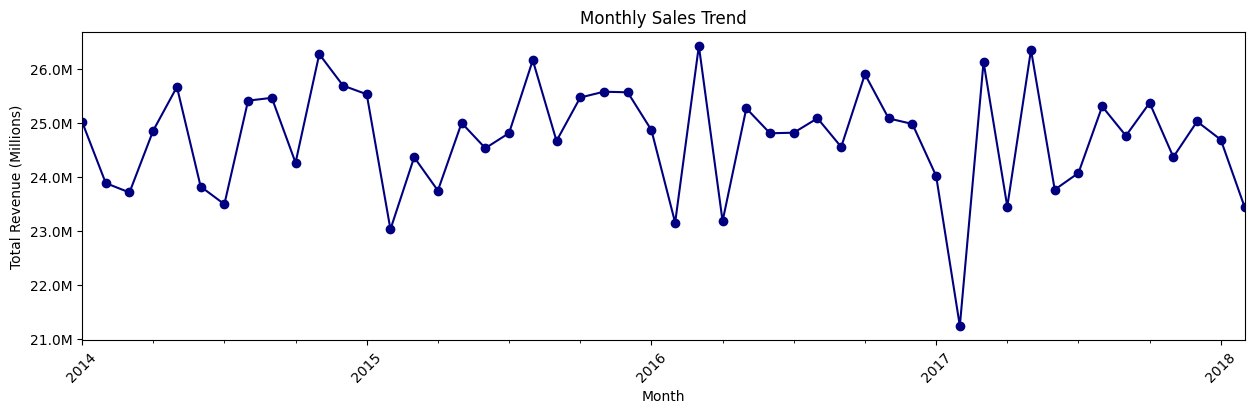

In [29]:
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('order_month')['revenue'].sum()
plt.figure(figsize=(15, 4))
monthly_sales.plot(marker = 'o', color= 'navy')

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)
plt.tight_layout
plt.show()

#### Insight
Sales consistently cycle between $23 Millions and $26 Milions, with clear peaks in late spring to early summer (May–June) and troughs each January.

The overall trend remains stable year over year, reflecting a reliable seasonal demand pattern.

However, the sharp revenue drop in early 2017 stands out as an outlier, warranting closer investigation into potential causes such as market disruptions or mistimed promotions.

#### 2. 📆 Monthly Sales Trend (All Years Combined)
Goal: Highlight overall seasonality patterns by aggregating sales across all years for each calendar month

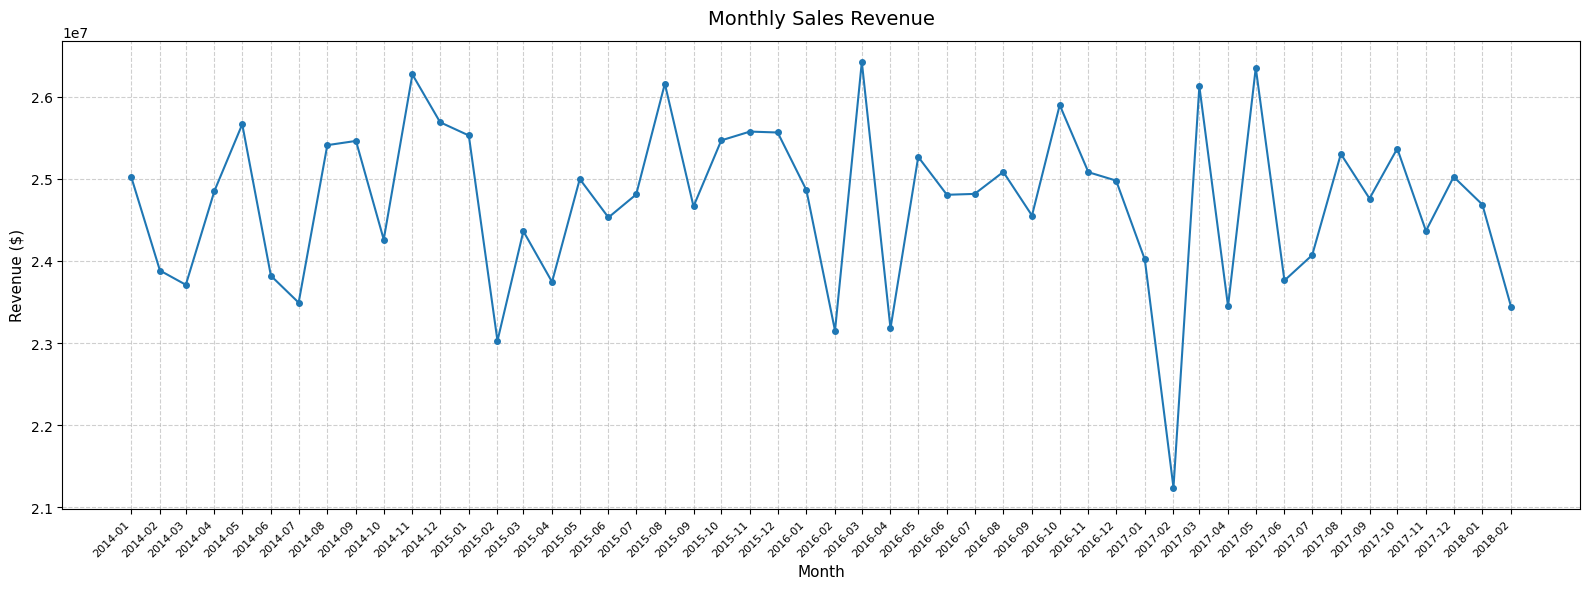

In [30]:
# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create Year-Month period
df['year_month'] = df['order_date'].dt.to_period('M')

# Aggregate revenue by month
monthly_sales = (
    df.groupby('year_month')['revenue']
      .sum()
      .reset_index()
)

# Convert period → timestamp for plotting
monthly_sales['date'] = monthly_sales['year_month'].dt.to_timestamp()

# Create label in format 2014-01, 2014-02, ...
monthly_sales['label'] = monthly_sales['year_month'].astype(str)

# Plot
plt.figure(figsize=(16, 6))

plt.plot(
    monthly_sales['date'],
    monthly_sales['revenue'],
    marker='o',
    markersize=4,
    linewidth=1.5,
    color='#1f77b4'
)

plt.title('Monthly Sales Revenue', fontsize=14, pad=12)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Revenue ($)', fontsize=11)

# Force show ALL month labels on x-axis
plt.xticks(
    monthly_sales['date'],
    monthly_sales['label'],
    rotation=45,
    ha='right',
    fontsize=8
)

# Format y-axis like the image (scientific notation)
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Observation:
This chart shows that the 2018 data covers only January and February. Consequently, an assessment of monthly sales trend (combined all years) would be skewed, as a full year's worth of data is required to analyze seasonal revenue patterns.

Exclude any partial-year data (i.e., January and February of 2018) so that the monthly totals aren’t skewed by an incomplete year.

Create df_new so I don’t alter the original df, preserving it intact for other analyses while filtering just for this chart.

In [31]:
# Filter out January and February 2018 orders
df_new = df[~((df['order_date'].dt.year == 2018) & 
          (df['order_date'].dt.month.isin([1, 2])))]


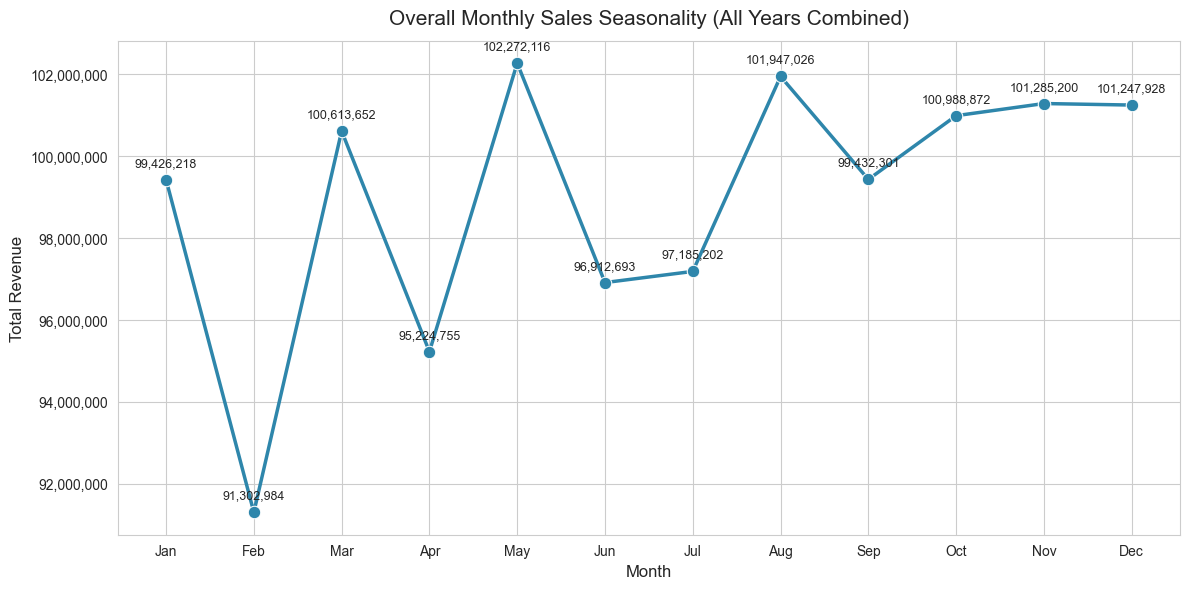

In [32]:
# Extract calendar month (1–12)
df_new['month'] = df_new['order_date'].dt.month
df_new['month_name'] = df_new['order_date'].dt.strftime('%b')

# Aggregate revenue by month across ALL years
monthly = (
    df_new.groupby(['month', 'month_name'], as_index=False)
      ['revenue'].sum()
      .sort_values('month')
)

# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.lineplot(
    data=monthly,
    x='month_name',
    y='revenue',
    marker='o',
    linewidth=2.5,
    markersize=9,
    color='#2E86AB'
)

plt.title('Overall Monthly Sales Seasonality (All Years Combined)', fontsize=15, pad=12)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Format numbers on the Y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Show revenue values on each point
for x, y in zip(monthly['month_name'], monthly['revenue']):
    ax.annotate(f'{y:,.0f}',
                (x, y),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center',
                fontsize=9)

plt.tight_layout()
plt.show()

#### Insight
Across all years, January begins strong with roughly $99M, followed by a steep decline through April’s low point (~$95M).

Sales rebound in May and August (~102M) before settling into a plateau of 99–101 Millions from September to December.

This pattern reveals a strong post–New Year surge, a spring dip, and a mid–summer bump each calendar year.

#### 3. 🏆 Top 10 Products by Revenue
Goal: Identify the highest-grossing products to focus marketing and inventory efforts

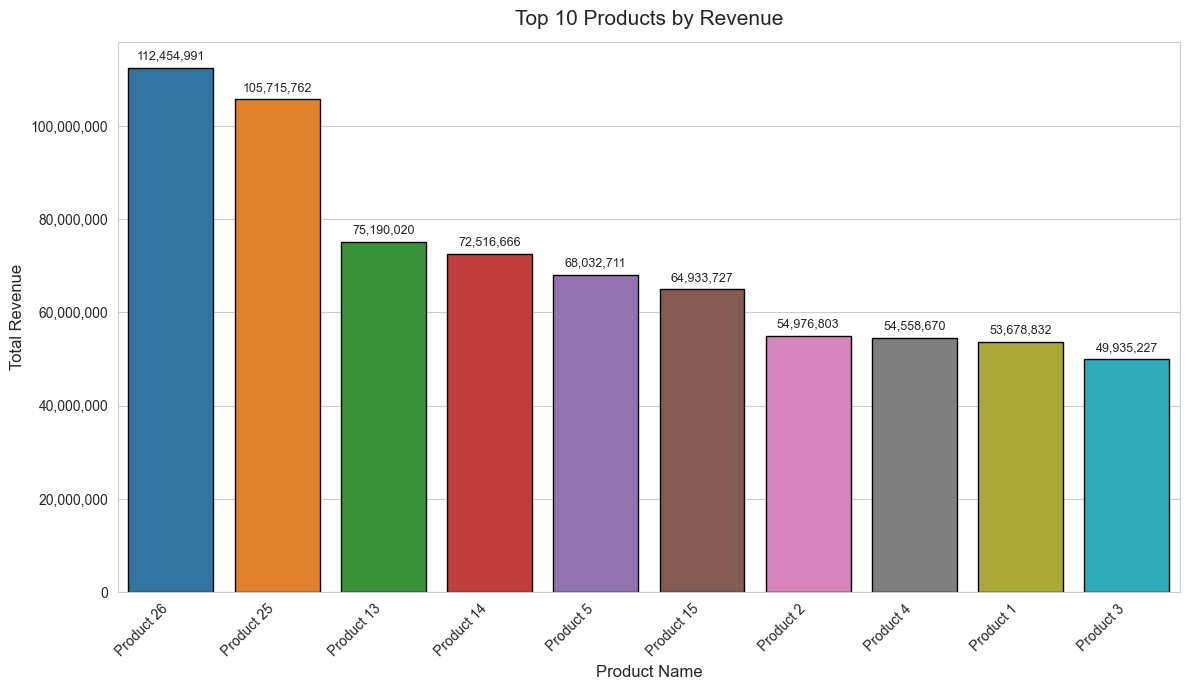

In [33]:
# Group by product and sum revenue
top_products = (
    df_new.groupby('product_name', as_index=False)
      ['revenue'].sum()
      .sort_values('revenue', ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Use a colorful palette
colors = sns.color_palette("tab10", n_colors=10)

ax = sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue',
    hue='product_name',          # to get different colors
    palette=colors,
    legend=False,
    edgecolor='black'
)

plt.title('Top 10 Products by Revenue', fontsize=15, pad=12)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9, xytext=(0, 4),
                textcoords='offset points')

plt.tight_layout()
plt.show()

#### Insight 
Products 26 and 25 pull away at $118M and $110M, with a sharp drop to 75 Millions for Product 13 and a tight mid-pack at $64–$72 Millions.

The bottom four cluster at $49–$54 Millions, highlighting similar constraints.

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.

#### 4. 💰 Top 10 Products by Avg Profit Margin
Goal: Compare average profitability across products to identify high-margin items

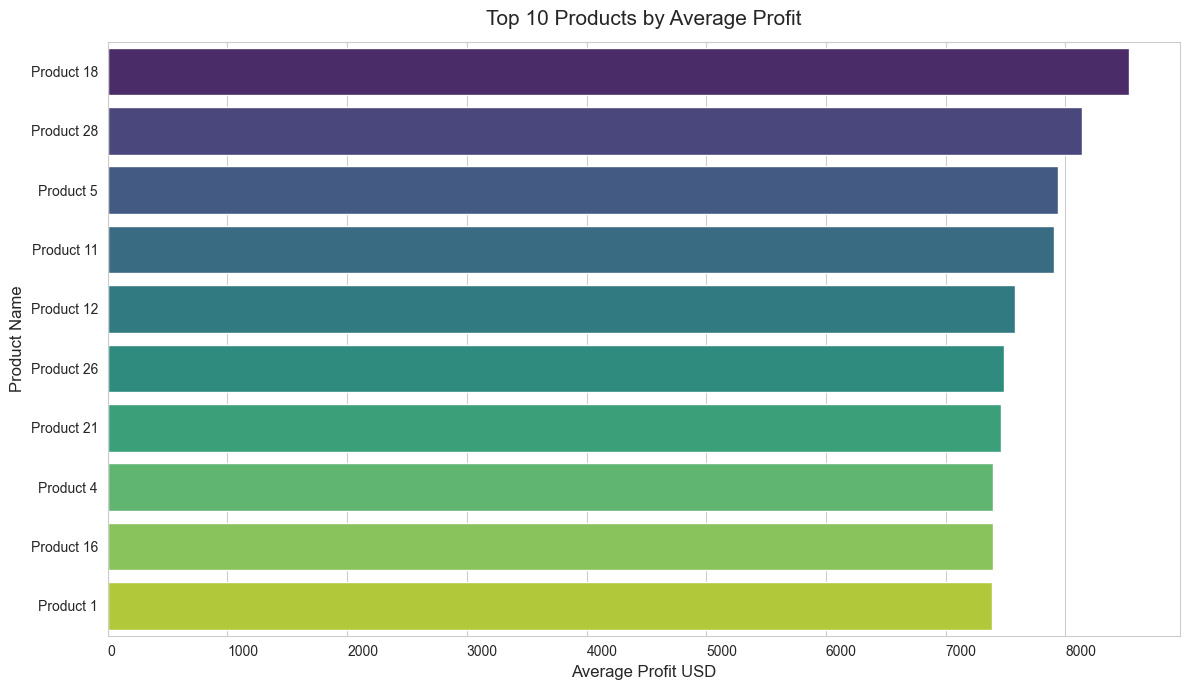

In [55]:
# Calculate average profit margin by product
top_margin_products = (
    df.groupby('product_name', as_index=False)
      .agg(avg_profit=('profit', 'mean'))
      .sort_values('avg_profit', ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

colors = sns.color_palette("viridis", n_colors=10)

ax = sns.barplot(
    data=top_margin_products,
    x='avg_profit',
    y='product_name',
    hue='product_name',
    palette=colors,
    legend=False,
)

# Add title and labels
plt.title('Top 10 Products by Average Profit', fontsize=15, pad=12)
plt.xlabel('Average Profit USD', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.xticks(rotation=0, ha='left')


plt.tight_layout()
plt.show()

#### Insight
Products 18 and 28 lead with average profit of approximately $8.0-$8.3K, followed closely by Product 5 and Product 11 around $7.9-$8.0K.

Mid-tier performers like Products 12, 26, and 21 cluster in the $7.4-7.6K range, while the bottom tier (Products 4, 16, and 1) fall between $7.2-7.4K.

Focusing on margin optimization strategies from top performers may help elevate overall product profitability.

#### 5. 🛒 Sales by Channel
Goal: Show distribution of total sales across channels to identify dominant sales routes

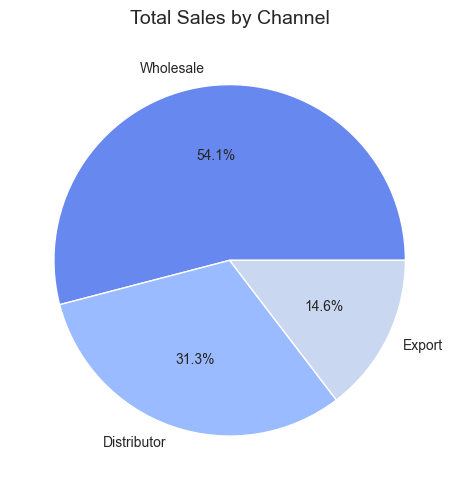

In [35]:
# Sales by Channels
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize = (5, 5))

plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm'),
)

plt.title('Total Sales by Channel', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

#### Insight
Wholesale accounts for 54% of sales, with distributors at ~31% and exports at ~15%, underscoring reliance on domestic bulk channels.

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives through targeted overseas marketing and strategic partner relationships.

#### 6. 💳 Average Order Value (AOV) Distribution
Goal: Understand distribution of order values to identify typical spending levels and outliers

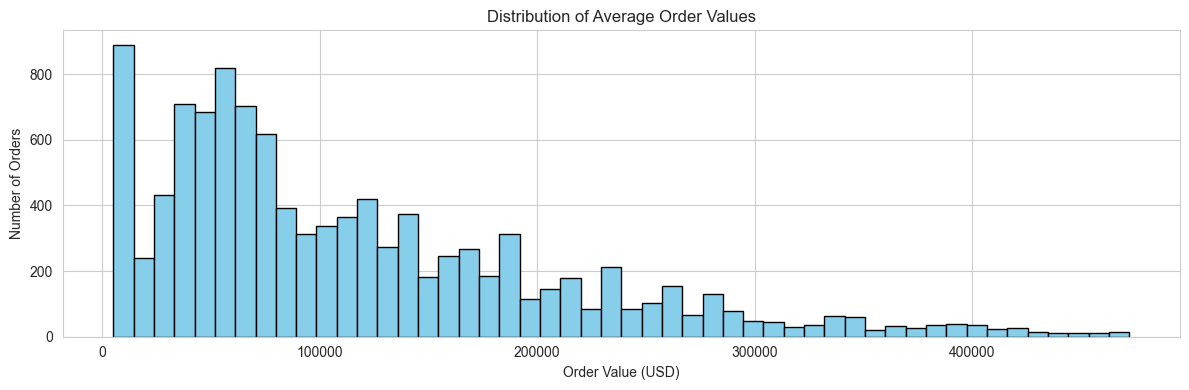

In [36]:
# Average Order Value (AOV) Distribution
aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize = (12,4))

plt.hist(
    aov,
    bins=50,
    color='skyblue',
    edgecolor='black'
)
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Average Order Values')

plt.tight_layout()
plt.show()

#### Insight
The Order value distribution is heavily right‐skewed, with most orders clustering between $20K and $120K and a pronounced mode around $50K - $60K.

A long tail of high value transactions extends up toward $400K - $500K, but these large orders represent only a small share of total volume.

#### 7. 🧾 Unit Price Distribution per Product
Goal: Compare pricing variability across different products to identify price consistency and outliers

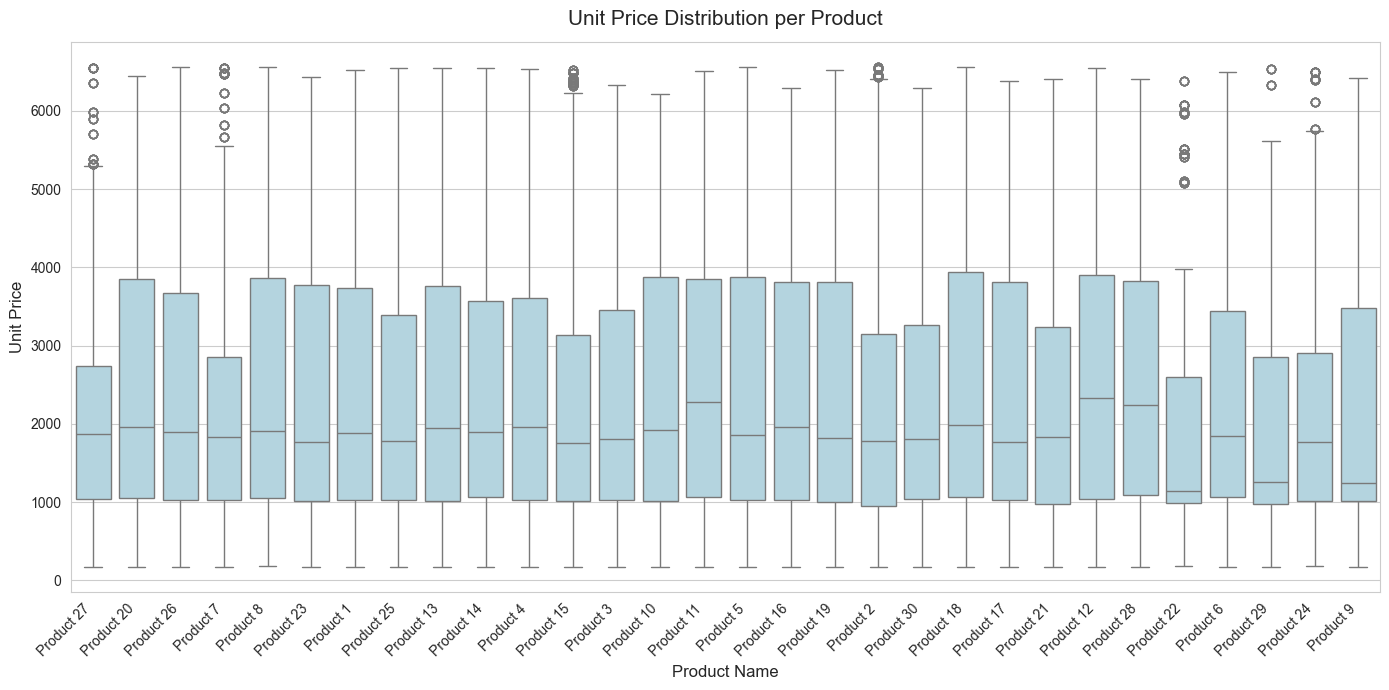

In [59]:
# Unit price distribution per product
top_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .index
)

df_plot = df[df['product_name'].isin(top_products)]

# Plot
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=df_plot,
    x='product_name',
    y='unit_price',
    color='lightblue'
)

# Add title and labels
plt.title('Unit Price Distribution per Product', fontsize=15, pad=12)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Unit Price', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Insight
Products 8, 17, 27, 20, and 28 show high-end likely due to bulk orders, special-edition releases, or premium bundles that temporarily inflate earnings.

In contrast, deep low-end outliers (near $0–$100) on Products 20 and 27 suggest promotional giveaways or test SKUs that pull down average prices.

To ensure accurate margin and pricing assessments, exclude these outlier transactions from average calculations.

Then assess whether such anomalies warrant formalization as ongoing promotional strategies or should be phased out to stabilize pricing performance.

#### 8. 🌎 Total Sales by US Region
Goal: Compare total sales across U.S regions to identify top performing markets and areas for targeted growth.

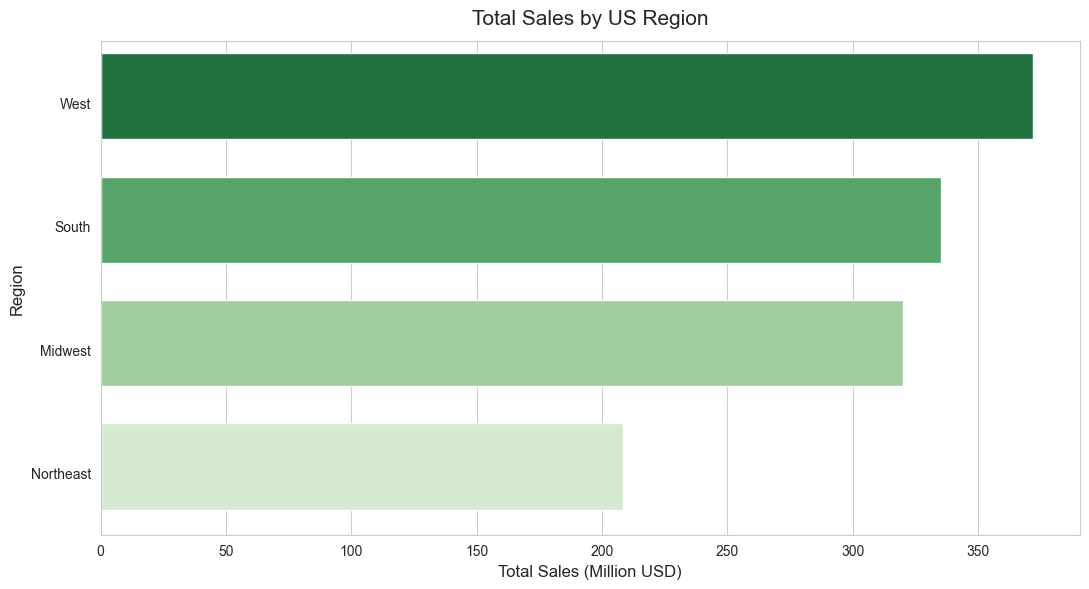

In [74]:
# Aggregate total sales by region
region_sales = (
    df.groupby('region', as_index=False)
      ['revenue'].sum()
    .sort_values('revenue', ascending=False)
)

# Convert to Million USD
region_sales['sales_million'] = region_sales['revenue'] / 1_000_000


# Plot
plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")

# Green gradient palette
colors = sns.color_palette("Greens_r", n_colors=len(region_sales))

ax = sns.barplot(
    data=region_sales,
    y='region',
    x='sales_million',
    hue='region',
    palette=colors,
    legend=False,
    height=0.7
)

plt.title('Total Sales by US Region', fontsize=15, pad=12)
plt.xlabel('Total Sales (Million USD)', fontsize=12)
plt.ylabel('Region', fontsize=12)


plt.tight_layout()
plt.show()

#### Insight
West dominates with roughly $360M in sales, underscoring its market leadership.

South and Midwest each contribute over $320M, indicating strong, consistent demand across central regions.

Northeast trails at about $210M, signaling room for growth and targeted investment.

Action: Focus on closing the Northeast gap with local promotions and strategic partnerships, while maintaining national playbook success.

#### 9. 🗺️ Top 10 States by Revenue and Order Count
Goal: Identify highest revenue-generating states and compare their order volumes

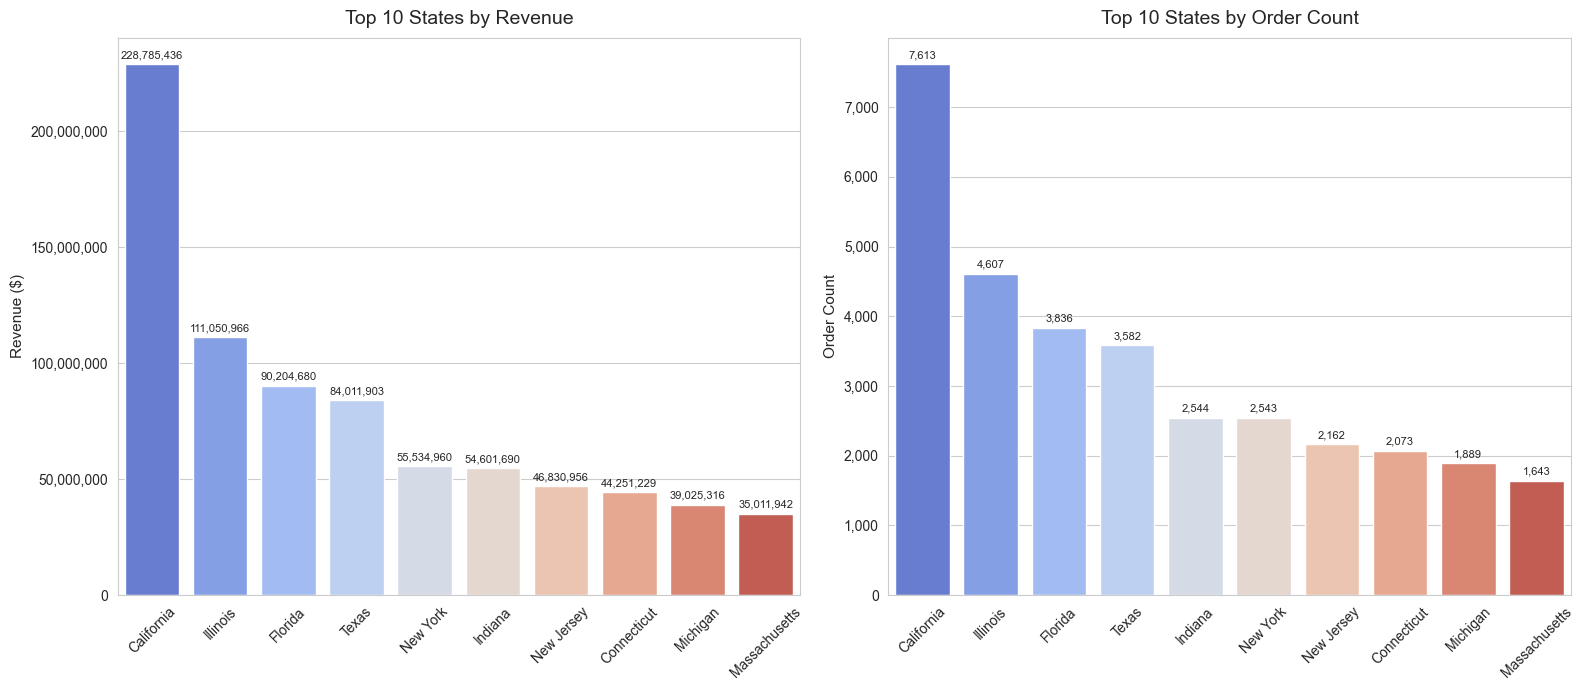

In [77]:
# Top 10 States by Revenue and order count
# Aggregate by state
state_summary = (
    df.groupby('state_name', as_index=False)
      .agg(
          total_revenue=('revenue', 'sum'),
          order_count=('order_number', 'nunique')
      )
)

# Top 10 by Revenue
top_revenue = state_summary.sort_values('total_revenue', ascending=False).head(10)

# Top 10 by Order Count
top_orders = state_summary.sort_values('order_count', ascending=False).head(10)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Color palette
colors = sns.color_palette("tab10", n_colors=10)

# Left chart: Top 10 States by Revenue
sns.barplot(
    data=top_revenue,
    x='state_name',
    y='total_revenue',
    hue='state_name',
    palette='coolwarm',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Top 10 States by Revenue', fontsize=14, pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Add value labels
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{height:,.0f}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                     textcoords='offset points')

# Right chart: Top 10 States by Order Count
sns.barplot(
    data=top_orders,
    x='state_name',
    y='order_count',
    hue='state_name',
    palette='coolwarm',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Top 10 States by Order Count', fontsize=14, pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Order Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Add value labels
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(f'{height:,.0f}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                     textcoords='offset points')

plt.tight_layout()
plt.show()

#### Insight
California leads by a wide margin, generating about $230M in revenue and 7600 orders, more than twice the next-highest state.

Illinois, Florida, and Texas form a solid second tier, each posting $84–110M in revenue with ~3600-4600 orders.

New York and Indiana are mid-pack (~$54–55M, ~2500 orders), while New Jersey, Connecticut, Michigan, and Massachusetts trail at $35–46M with ~1600-2100 orders.

The close alignment between revenue and order counts suggests similar average order values across states; to drive growth, focus on increasing order volume in the mid-tier and raising order size in lower-performing regions.

#### 10. 📈 Average Profit Margin by Channel
Goal: Compare average profit margins across sales channels to identify the most and least profitable routes


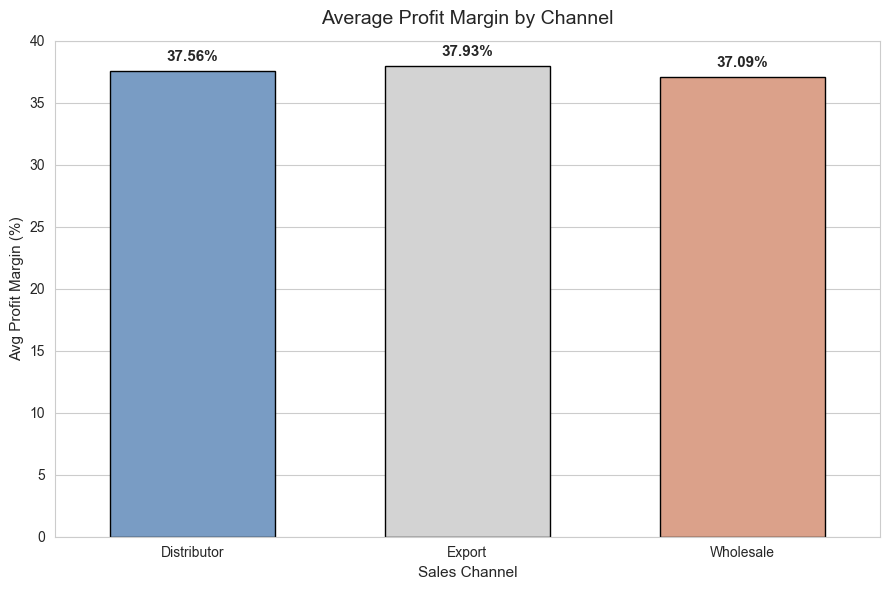

In [39]:
# Average profit margin by Channel
# Calculate profit margin
df['profit_margin'] = (df['revenue'] - df['total_cost']) / df['revenue']

# Average profit margin by channel
channel_margin = (
    df.groupby('channel', as_index=False)
      ['profit_margin']
      .mean()
)

# Optional: convert to percentage for easier plotting
channel_margin['profit_margin_pct'] = channel_margin['profit_margin'] * 100

# Plot
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# Custom colors matching the image
colors = ['#6C9BD1', '#D3D3D3', '#E89B7D']   # blue, gray, salmon

ax = sns.barplot(
    data=channel_margin,
    x='channel',
    y='profit_margin_pct',
    hue='channel',
    palette=colors,
    legend=False,
    edgecolor='black',
    width=0.6
)

plt.title('Average Profit Margin by Channel', fontsize=14, pad=12)
plt.xlabel('Sales Channel', fontsize=11)
plt.ylabel('Avg Profit Margin (%)', fontsize=11)

# Set y-axis limit 
plt.ylim(0, 40)

# Add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

#### Insight
Export leads with a 37.93% average margin, closely followed by Distributor (37.56%) and Wholesale (37.09%).

The tiny spread (<0.2%) shows consistently strong profitability across all channels.

This uniformity implies well-controlled costs and pricing power everywhere.

To maximize returns, push volume growth in Export while maintaining efficiency in Distributor and Wholesale.

#### 11. 👥 Top and Bottom 10 Customers by Revenue
Goal: Identify your highest- and lowest-revenue customers to tailor engagement strategies

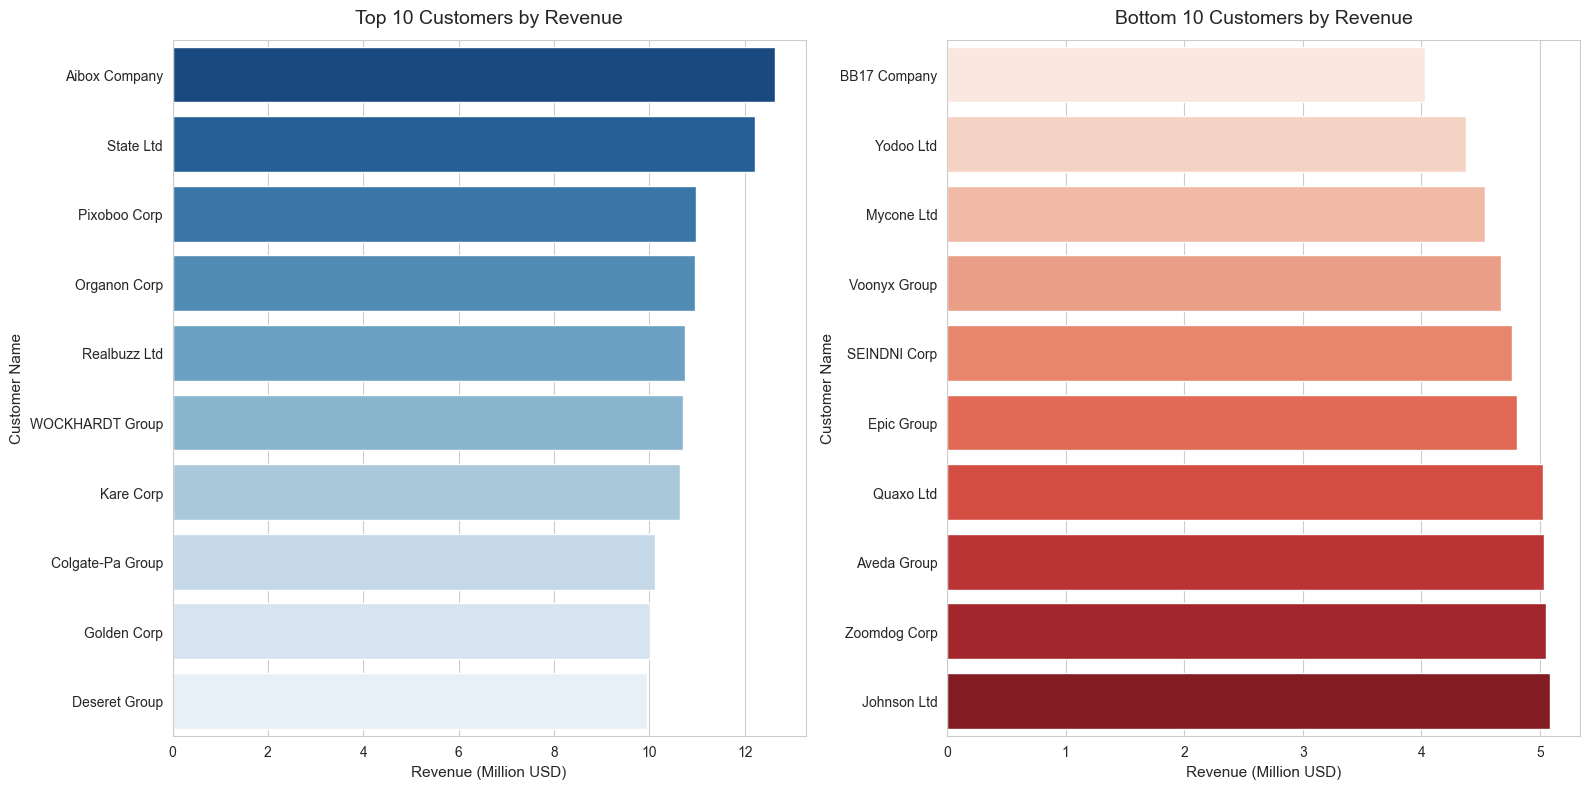

In [40]:
# Aggregate revenue by customer
customer_revenue = (
    df.groupby('customer_names', as_index=False)
      ['revenue'].sum()
)

# Top 10 (highest first)
top_10 = customer_revenue.sort_values('revenue', ascending=False).head(10)

# Bottom 10 (lowest first)
bottom_10 = customer_revenue.sort_values('revenue', ascending=True).head(10)

# Convert to Million USD for display
top_10['revenue_m'] = top_10['revenue'] / 1_000_000
bottom_10['revenue_m'] = bottom_10['revenue'] / 1_000_000

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Top 10 Customers
# Blue gradient (darker = higher revenue)
colors_top = sns.color_palette("Blues_r", n_colors=10)

sns.barplot(
    data=top_10,
    y='customer_names',
    x='revenue_m',
    hue='customer_names',
    palette=colors_top,
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Top 10 Customers by Revenue', fontsize=14, pad=12)
axes[0].set_xlabel('Revenue (Million USD)', fontsize=11)
axes[0].set_ylabel('Customer Name', fontsize=11)

# Right: Bottom 10 Customers
# Red gradient
colors_bottom = sns.color_palette("Reds", n_colors=10)

sns.barplot(
    data=bottom_10,
    y='customer_names',
    x='revenue_m',
    hue='customer_names',
    palette=colors_bottom,
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Bottom 10 Customers by Revenue', fontsize=14, pad=12)
axes[1].set_xlabel('Revenue (Million USD)', fontsize=11)
axes[1].set_ylabel('Customer Name', fontsize=11)

plt.tight_layout()
plt.show()

#### Insight 
Aibox Company tops the list with $12.5M, followed closely by State Ltd ($12.2M), while the 10th-ranked Deseret Group still contributes $9.9M, demonstrating a tight $10–12 M top tier.

At the bottom, Johnson Ltd leads its group with $5.1M, down to BB17 Company at $4.1M, roughly half the top customer’s revenue.

This steep drop from ~$10M+ to $4–5M highlights high revenue concentration among the top customers.

Action: prioritize retention and upsell for your top ten, and launch targeted growth campaigns to elevate the lower-revenue cohort.

#### 12. 🎯 Customer Segmentation: Revenue vs. Profit Margin
Goal: Segment customers by total revenue and average profit margin, highlighting order volume.

Using Bubble chart. Scatter points sized by number of orders, plotting revenue vs. margin

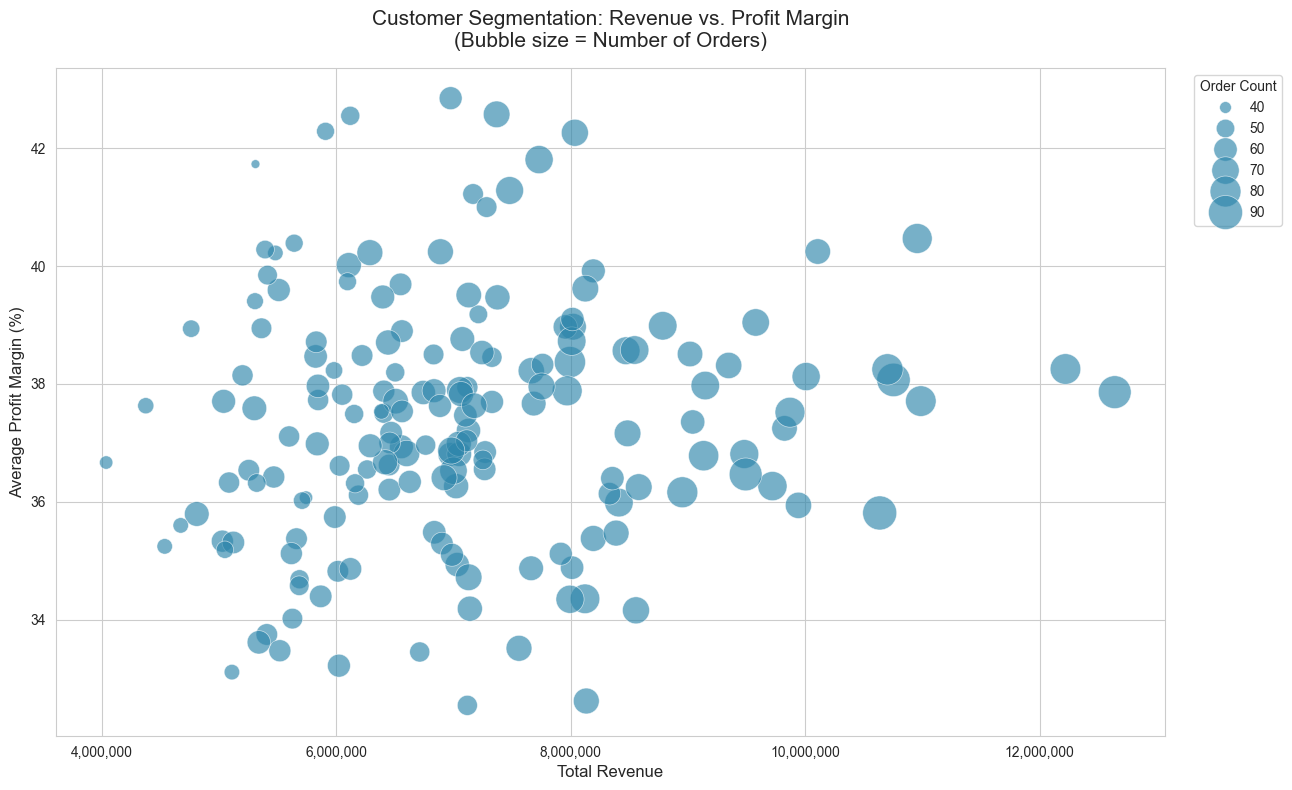

In [41]:
# Aggregate by customer
customer_seg = (
    df.groupby('customer_names', as_index=False)
      .agg(
          total_revenue=('revenue', 'sum'),
          avg_profit_margin=('profit_margin_pct', 'mean'),
          order_count=('order_number', 'nunique')          # number of orders
      )
)

# Plot - Bubble Chart
plt.figure(figsize=(13, 8))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=customer_seg,
    x='total_revenue',
    y='avg_profit_margin',
    size='order_count',                # bubble size = order volume
    sizes=(40, 600),                   # min and max bubble size
    alpha=0.65,
    color='#2E86AB',
    linewidth=0.5
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin\n(Bubble size = Number of Orders)', 
          fontsize=15, pad=15)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Average Profit Margin (%)', fontsize=12)

# Format axes
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Improve legend
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Order Count', 
           bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

#### Insight
Customers with > $10M in revenue tend to sustain margins between 36–40%, indicating that scale does not significantly erode profitability.

Most customers cluster within the $6–10 M range and show stable margins (~34–40%), suggesting consistent pricing in this tier.

Customers below $6 M display the widest margin variance (~33–43%), pointing to more volatile cost structures or discounts among smaller accounts.

Bubble size (order count) increases with revenue, but margin levels appear unaffected—reinforcing revenue as the dominant performance driver over order volume.

#### 13. 🔗 Correlation Heatmap of Numeric Features
Goal: Identify relationships among key numeric variables to uncover potential multicollinearity

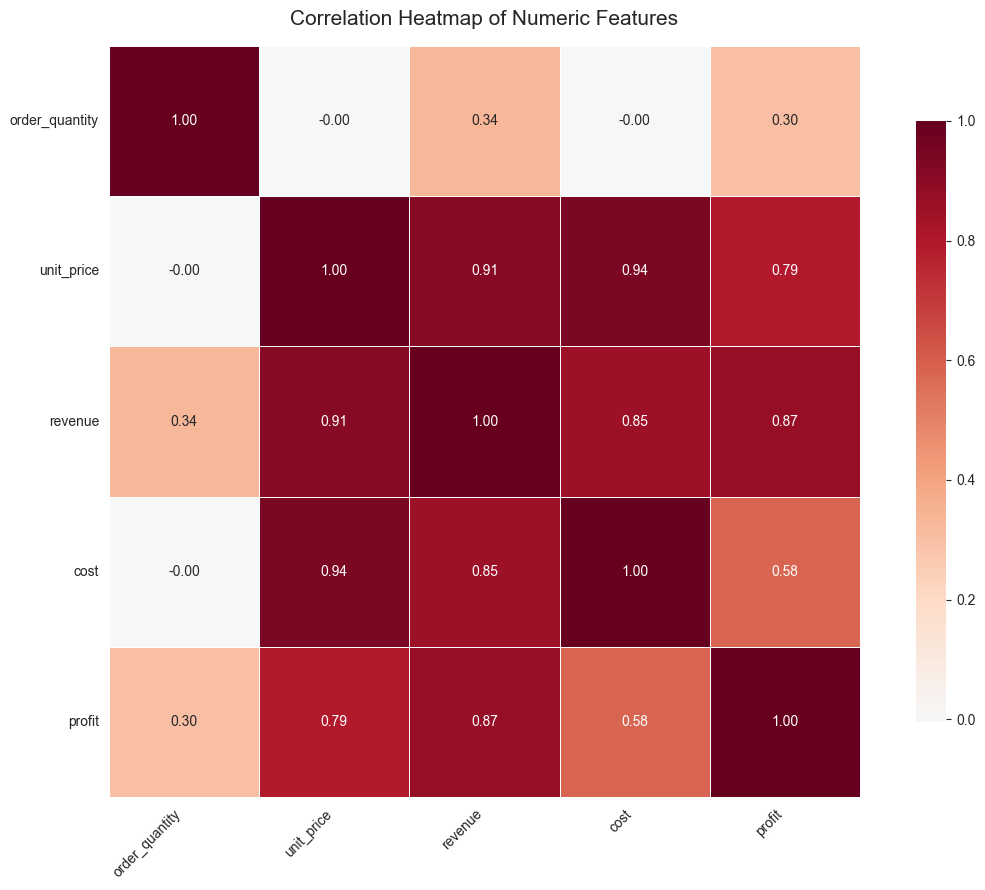

In [42]:
# Select numeric columns to analyze correlation
num_cols = ['order_quantity', 'unit_price', 'revenue', 'cost', 'profit']

# Calculate correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.set_style("white")

sns.heatmap(
    corr_matrix,
    annot=True,              # show correlation values
    fmt=".2f",               # 2 decimal places
    cmap='RdBu_r',           # red-blue diverging colormap
    center=0,                # center the colormap at 0
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Heatmap of Numeric Features', fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Insight
Profit and revenue are very strongly correlated (1.00), indicating that as sales value increases, profit tends to rise as well.

Unit price is a key driver: it correlates 0.91 with revenue, 0.9 with profit, and 0.94 with cost. Highlighting how pricing decisions ripple through both top‑line and expense figures.

Cost shows a strong link to revenue (0.85) and profit (0.83). As costs rise, both revenue and profit increase, demonstrating a business model that maintains stable profit margins and leverages costs effectively to drive growth.

Quantity has virtually no correlation with unit price or cost (≈0.00) and only modest associations with revenue (0.34) and profit (0.36), making volume a secondary factor compared to pricing.